# Dense periodic n=1: historical GC and signed-lag TDMI

## 1. Objective and timing

This compact analysis asks whether the deterministic event indicator $E_i$ incrementally predicts the powered volatility state and its change, whether reverse predictability is present, and how the results vary by cumulative GC history order, individual driver lag, and signed TDMI lag.

For frozen $n=1$, $X_i=sigma_i$. Timing is $E_i -> omega_{i+1} -> X_{i+1}$: event age 0 first affects state lag $+1$, so ages 0 through 12 map to $+1$ through $+13$. The event period is 21 transitions. The direct-response window is $+1,...,+13$; the strict inter-event window is $+1,...,+20$; $+21$ is the next-event boundary. TDMI scans $-34,...,0,...,+34$; positive lag means event leads the target.

## 2. Load the frozen benchmark simulation

Notebook 01 directly loads the canonical Notebook 00 and reuses its validated benchmark configuration, timing and simulated path. No simulator, parameter, calendar or shock is reconstructed.

In [1]:
%%capture
%run "./00_model_specification_and_core_simulator.ipynb"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown, display

assert {'reference_config','reference_timing','reference_result'}.issubset(globals())
assert reference_config['model']['n'] == 1
states, transitions = reference_result['states'].copy(), reference_result['transitions'].copy()
DIRECT_END, INTER_EVENT_END, NEXT_EVENT_BOUNDARY, TDMI_MAX_LAG = 13, 20, 21, 34
assert reference_timing['response_horizon_steps'] + 1 == DIRECT_END
assert reference_timing['event_period_steps'] == NEXT_EVENT_BOUNDARY
print('Frozen n=1 benchmark loaded.')

## 3. Construct aligned level and change series

The level pair is $(E_i,X_i)$ at transition source times. The change pair is $(E_i,Delta X_i)$, with $Delta X_i=X_i-X_{i-1}$ and the first state omitted. Every historical GC row for response index $i$ uses only $i-1,...,i-p$ in both target and driver histories.

In [2]:
level_table = pd.DataFrame({'i': transitions['i'].to_numpy(int), 'event': transitions['event'].to_numpy(float), 'state': states.iloc[:-1]['x'].to_numpy(float)})
change_table = pd.DataFrame({'i': transitions['i'].iloc[1:].to_numpy(int), 'event': transitions['event'].iloc[1:].to_numpy(float), 'state_change': states['x'].to_numpy(float)[1:-1] - states['x'].to_numpy(float)[:-2]})
series_map = {'Powered-state level': (level_table.state.to_numpy(), level_table.event.to_numpy()), 'Powered-state change': (change_table.state_change.to_numpy(), change_table.event.to_numpy())}
for target, event in series_map.values(): assert len(target) == len(event) and np.isfinite(target).all() and np.isfinite(event).all()
assert set(level_table.event.unique()).issubset({0.,1.}) and set(change_table.event.unique()).issubset({0.,1.})
print(f'Level rows: {len(level_table)}; change rows: {len(change_table)}.')

Level rows: 504; change rows: 503.


## 4. Bidirectional historical GC

For target $Y$ and driver $Z$, restricted OLS contains an intercept and $Y_{i-1},...,Y_{i-p}$; unrestricted OLS additionally contains $Z_{i-1},...,Z_{i-p}$. The nested-regression F statistic jointly tests added driver history. Every order $p=1,...,20$ uses the response rows available at $p=20$, preventing sample-size confounding. A GC order is a cumulative history, not an individual causal lag.

For reverse directions only, `GC_DEGENERACY_TOL = 1e-12` flags a restricted event model when either restricted RSS or restricted residual variance is at or below that threshold. The deterministic-calendar boundary remains visible, but its undefined inferential statistics and selection criteria are excluded.

In [3]:
GC_MAX_ORDER = 20
GC_DEGENERACY_TOL = 1e-12
REVERSE_GC_DIRECTIONS = {'state level -> event', 'state change -> event'}

def build_gc_design(target, driver, order, common_max_order=GC_MAX_ORDER):
    target, driver = np.asarray(target,float), np.asarray(driver,float)
    if target.ndim != 1 or driver.ndim != 1 or len(target) != len(driver) or not 1 <= order <= common_max_order < len(target): raise ValueError('invalid historical GC inputs or order.')
    response_index = np.arange(common_max_order,len(target))
    target_history = np.column_stack([target[response_index-j] for j in range(1,order+1)])
    driver_history = np.column_stack([driver[response_index-j] for j in range(1,order+1)])
    assert np.all(np.column_stack([response_index-j for j in range(1,order+1)]) < response_index[:,None])
    return target[response_index], sm.add_constant(target_history,has_constant='add'), sm.add_constant(np.column_stack([target_history,driver_history]),has_constant='add'), response_index

def restricted_model_is_degenerate(restricted):
    return bool(restricted.ssr <= GC_DEGENERACY_TOL or restricted.mse_resid <= GC_DEGENERACY_TOL)

def run_gc_order_scan(target,driver,target_name,direction):
    rows=[]
    for order in range(1,GC_MAX_ORDER+1):
        y,xr,xu,_=build_gc_design(target,driver,order); restricted,unrestricted=sm.OLS(y,xr).fit(),sm.OLS(y,xu).fit()
        r,u,q,df=restricted.ssr,unrestricted.ssr,order,unrestricted.df_resid
        degenerate = direction in REVERSE_GC_DIRECTIONS and restricted_model_is_degenerate(restricted)
        if degenerate:
            f,p_value,partial_r2,log_ratio,aic,bic = (np.nan,)*6
        else:
            f=((r-u)/q)/(u/df); p_value=stats.f.sf(f,q,df); partial_r2=(r-u)/r; log_ratio=np.log(r/u); aic=unrestricted.aic; bic=unrestricted.bic
        rows.append({'target':target_name,'direction':direction,'lag_order':order,'restricted_RSS':float(r),'unrestricted_RSS':float(u),'restricted_residual_variance':float(restricted.mse_resid),'restricted_model_degenerate':degenerate,'F_statistic':float(f),'p_value':float(p_value),'partial_R_squared':float(partial_r2),'log_variance_ratio':float(log_ratio),'unrestricted_AIC':float(aic),'unrestricted_BIC':float(bic),'n_observations':int(unrestricted.nobs)})
    return pd.DataFrame(rows)

def select_gc_orders(scan,upper,window):
    data=scan.loc[scan.lag_order.le(upper)]; valid=data.loc[~data.restricted_model_degenerate].dropna(subset=['unrestricted_AIC','unrestricted_BIC','partial_R_squared'])
    if valid.empty: raise ValueError('no non-degenerate GC orders available for selection.')
    aic=valid.loc[valid.unrestricted_AIC.idxmin()]; bic=valid.loc[valid.unrestricted_BIC.idxmin()]; r2=valid.loc[valid.partial_R_squared.idxmax()]
    return {'target':aic.target,'direction':aic.direction,'search window':window,'valid candidate-order range':f"p={int(valid.lag_order.min())}..{int(valid.lag_order.max())}",'AIC-selected order':int(aic.lag_order),'BIC-selected order':int(bic.lag_order),'max-partial-R2 order':int(r2.lag_order),'any order excluded as degenerate':bool(data.restricted_model_degenerate.any()),'selected F-statistic':float(aic.F_statistic),'selected p-value':float(aic.p_value),'selected partial R-squared':float(aic.partial_R_squared),'selected log variance ratio':float(aic.log_variance_ratio)}

def run_individual_lag_tests(target,driver,target_name,direction):
    y,_,xu,_=build_gc_design(target,driver,GC_MAX_ORDER); model=sm.OLS(y,xu).fit(); rows=[]
    for lag in range(1,GC_MAX_ORDER+1):
        idx=1+GC_MAX_ORDER+lag-1; coef,se=float(model.params[idx]),float(model.bse[idx]); t=coef/se
        rows.append({'target':target_name,'direction':direction,'lag':lag,'coefficient':coef,'standard_error':se,'t_statistic':t,'partial_F_statistic':t*t,'raw_p_value':float(2*stats.t.sf(abs(t),model.df_resid))})
    table=pd.DataFrame(rows); reject,adjusted,_,_=multipletests(table.raw_p_value,method='holm'); table['Holm_adjusted_p_value']=adjusted; table['survives_Holm_correction']=reject
    return table

gc_specs=[('Powered-state level','event -> state level',*series_map['Powered-state level']),('Powered-state level','state level -> event',series_map['Powered-state level'][1],series_map['Powered-state level'][0]),('Powered-state change','event -> state change',*series_map['Powered-state change']),('Powered-state change','state change -> event',series_map['Powered-state change'][1],series_map['Powered-state change'][0])]
gc_scan=pd.concat([run_gc_order_scan(y,z,name,direction) for name,direction,y,z in gc_specs],ignore_index=True)
individual_lag_table=pd.concat([run_individual_lag_tests(y,z,name,direction) for name,direction,y,z in gc_specs],ignore_index=True)

## 5. Full signed-lag TDMI

The primary estimator applies fixed empirical quantile edges from `qcut` using the inherited primary setting of 10 bins and calculates $I(E_i;Y_{i+tau})$ directly from contingency-table probabilities. Mutual information is symmetric; signed lag supplies temporal interpretation.

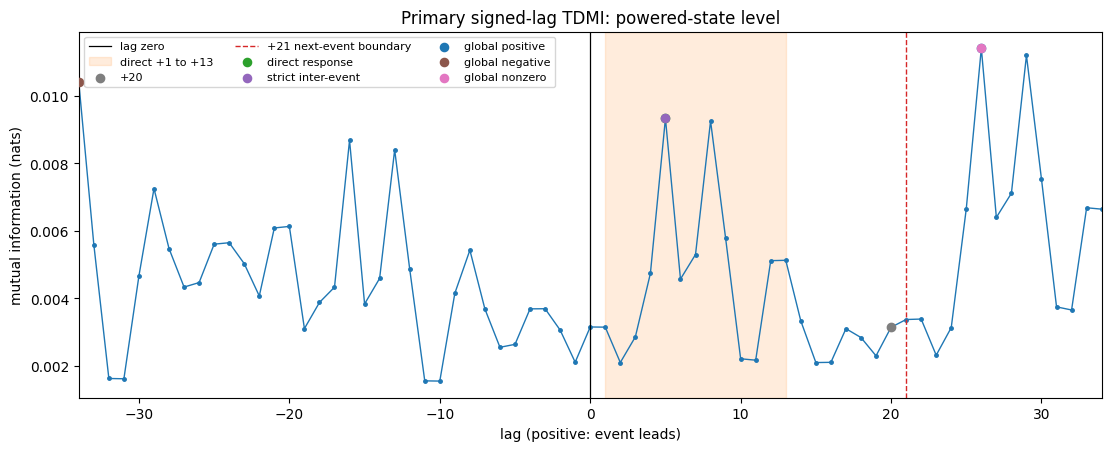

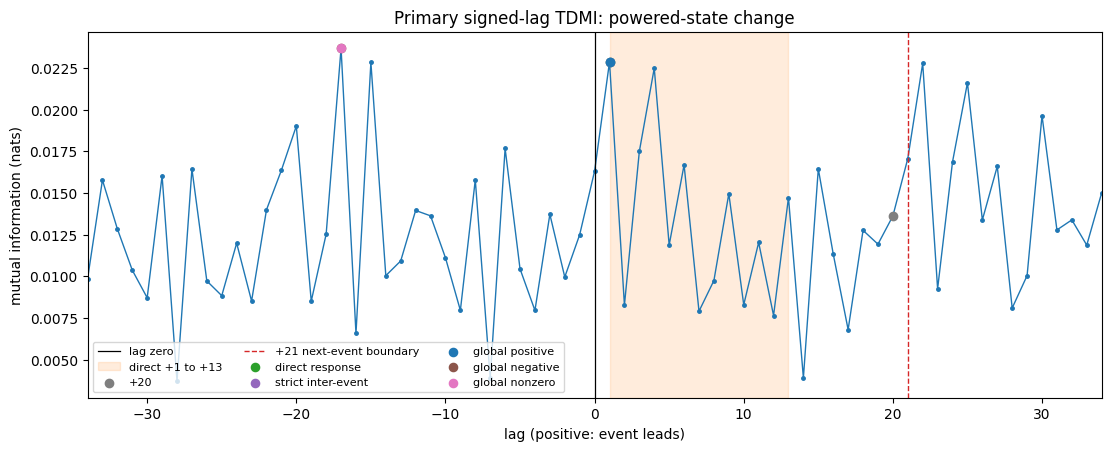

In [4]:
def tdmi_pairs(event,target,lag):
    event,target=np.asarray(event,int),np.asarray(target,float)
    return (event[:-lag],target[lag:]) if lag>0 else ((event[-lag:],target[:lag]) if lag<0 else (event,target))
def fixed_quantile_edges(values,bins):
    _,edges=pd.qcut(pd.Series(values,dtype=float),q=bins,retbins=True,duplicates='drop'); edges=np.asarray(edges,float)
    if len(edges)<3: raise ValueError('fewer than two TDMI bins.')
    edges[0],edges[-1]=-np.inf,np.inf; return edges
def mi_from_counts(event,bins):
    counts=pd.crosstab(pd.Series(event),pd.Series(bins),dropna=False).to_numpy(float); joint=counts/counts.sum(); independent=joint.sum(1,keepdims=True)@joint.sum(0,keepdims=True); nonzero=joint>0
    return float(np.sum(joint[nonzero]*np.log(joint[nonzero]/independent[nonzero])))
def compute_tdmi_curve(event,target,bins=10):
    edges=fixed_quantile_edges(target,bins); rows=[]
    for lag in range(-TDMI_MAX_LAG,TDMI_MAX_LAG+1):
        e,y=tdmi_pairs(event,target,lag); b=pd.cut(pd.Series(y),bins=edges,labels=False,include_lowest=True); rows.append({'lag':lag,'n_pairs':len(e),'mutual_information':mi_from_counts(e,b.to_numpy(int))})
    return pd.DataFrame(rows)
def summarise_tdmi_windows(curve,target_name):
    windows=[('direct response',1,DIRECT_END,'event response'),('strict inter-event',1,INTER_EVENT_END,'before next event'),('next-event boundary',NEXT_EVENT_BOUNDARY,NEXT_EVENT_BOUNDARY,'next scheduled event'),('global positive',1,TDMI_MAX_LAG,'event leads target'),('global negative',-TDMI_MAX_LAG,-1,'target leads event'),('global nonzero',-TDMI_MAX_LAG,TDMI_MAX_LAG,'largest nonzero dependence'),('lag zero',0,0,'contemporaneous dependence')]; rows=[]
    for window,lo,hi,text in windows:
        data=curve.loc[curve.lag.between(lo,hi)]; data=data.loc[data.lag.ne(0)] if window=='global nonzero' else data; best=data.nlargest(1,'mutual_information').iloc[0]; boundary=bool(best.lag in {-TDMI_MAX_LAG,TDMI_MAX_LAG})
        rows.append({'target':target_name,'window':window,'best lag':int(best.lag),'TDMI value':float(best.mutual_information),'boundary maximum':boundary,'interpretation':text+('; scan-boundary maximum' if boundary else '')})
    return pd.DataFrame(rows)
def plot_tdmi_curve(curve,summary,target_name):
    fig,ax=plt.subplots(figsize=(11,4.4),constrained_layout=True); ax.plot(curve.lag,curve.mutual_information,marker='o',markersize=2.5,linewidth=1); ax.axvline(0,color='black',linewidth=.9,label='lag zero'); ax.axvspan(1,DIRECT_END,color='tab:orange',alpha=.14,label='direct +1 to +13')
    at20=curve.loc[curve.lag.eq(INTER_EVENT_END)].iloc[0]; ax.scatter(INTER_EVENT_END,at20.mutual_information,color='tab:gray',zorder=4,label='+20'); ax.axvline(NEXT_EVENT_BOUNDARY,color='tab:red',linestyle='--',linewidth=1,label='+21 next-event boundary')
    for window,color in {'direct response':'tab:green','strict inter-event':'tab:purple','global positive':'tab:blue','global negative':'tab:brown','global nonzero':'tab:pink'}.items():
        row=summary.loc[summary.window.eq(window)].iloc[0]; ax.scatter(row['best lag'],row['TDMI value'],color=color,s=35,zorder=5,label=window)
    ax.set(title=f'Primary signed-lag TDMI: {target_name}',xlabel='lag (positive: event leads)',ylabel='mutual information (nats)',xlim=(-TDMI_MAX_LAG,TDMI_MAX_LAG)); ax.legend(ncol=3,fontsize=8); plt.show()
level_tdmi=compute_tdmi_curve(level_table.event,level_table.state); level_tdmi_summary=summarise_tdmi_windows(level_tdmi,'Powered-state level'); plot_tdmi_curve(level_tdmi,level_tdmi_summary,'powered-state level')
change_tdmi=compute_tdmi_curve(change_table.event,change_table.state_change); change_tdmi_summary=summarise_tdmi_windows(change_tdmi,'Powered-state change'); plot_tdmi_curve(change_tdmi,change_tdmi_summary,'powered-state change')

## Key lag and direction results

The three lag concepts remain separate: AIC/BIC select a cumulative GC history, the distributed-lag model identifies the strongest conditional driver coefficient, and TDMI identifies a descriptive signed-lag dependence peak.

In [5]:
selection_rows=[]; strongest_rows=[]; lag20_rows=[]
for target_name,direction,_,_ in gc_specs:
    scan=gc_scan.loc[gc_scan.direction.eq(direction)]; selection_rows += [select_gc_orders(scan,DIRECT_END,'direct response p=1..13'),select_gc_orders(scan,INTER_EVENT_END,'strict inter-event p=1..20')]
    lags=individual_lag_table.loc[individual_lag_table.direction.eq(direction)]; direct=lags.loc[lags.lag.between(1,DIRECT_END)].nlargest(1,'partial_F_statistic').iloc[0]; inter=lags.loc[lags.lag.between(1,INTER_EVENT_END)].nlargest(1,'partial_F_statistic').iloc[0]
    for label,row in [('direct response lag=1..13',direct),('strict inter-event lag=1..20',inter)]: strongest_rows.append({'target':target_name,'direction':direction,'lag window':label,'strongest lag':int(row.lag),'coefficient':float(row.coefficient),'partial F-statistic':float(row.partial_F_statistic),'raw p-value':float(row.raw_p_value),'Holm-adjusted p-value':float(row.Holm_adjusted_p_value),'survives Holm correction':bool(row.survives_Holm_correction)})
    at20=lags.loc[lags.lag.eq(INTER_EVENT_END)].iloc[0]; lag20_rows.append({'target':target_name,'direction':direction,'lag 20 partial F':at20.partial_F_statistic,'lag 20 raw p':at20.raw_p_value,'direct-window winner':int(direct.lag)})
gc_order_selection_table=pd.DataFrame(selection_rows); strongest_individual_lag_table=pd.DataFrame(strongest_rows); lag20_comparison=pd.DataFrame(lag20_rows); tdmi_best_lag_table=pd.concat([level_tdmi_summary,change_tdmi_summary],ignore_index=True)
print('Table A: cumulative GC order selection (AIC primary; BIC sensitivity)'); display(gc_order_selection_table.style.format({'selected F-statistic':'{:.4f}','selected p-value':'{:.3e}','selected partial R-squared':'{:.6f}','selected log variance ratio':'{:.6f}'}))
print('Because the periodic calendar can make reverse lag coefficients near the event period reflect phase and multicollinearity, they are not structural-causation evidence.')
print('Because the event indicator is deterministic and periodic with period 21, reverse p=20 rows with numerically collapsed restricted residual variance are deterministic-calendar boundary diagnostics and are excluded from inferential order selection.')
print('Table B: strongest individual distributed-lag driver coefficient'); display(strongest_individual_lag_table.style.format({'coefficient':'{:.6g}','partial F-statistic':'{:.4f}','raw p-value':'{:.3e}','Holm-adjusted p-value':'{:.3e}'}))
print('Reverse-GC note: p=20 is excluded from order selection when its restricted event residual variance is numerically degenerate.');
print('TDMI best lags by window'); display(tdmi_best_lag_table.style.format({'TDMI value':'{:.6f}'}))
for _,row in lag20_comparison.loc[lag20_comparison['direct-window winner'].ne(INTER_EVENT_END)].iterrows(): print(f"{row.direction}: lag 20 partial F={row['lag 20 partial F']:.3f}, distinct from direct-window winner lag {int(row['direct-window winner'])}.")

Table A: cumulative GC order selection (AIC primary; BIC sensitivity)


,target,direction,search window,valid candidate-order range,AIC-selected order,BIC-selected order,max-partial-R2 order,any order excluded as degenerate,selected F-statistic,selected p-value,selected partial R-squared,selected log variance ratio
0,Powered-state level,event -> state level,direct response p=1..13,p=1..13,6,1,10,False,8.8487,3.699e-09,0.101304,0.106810
1,Powered-state level,event -> state level,strict inter-event p=1..20,p=1..20,6,1,10,False,8.8487,3.699e-09,0.101304,0.106810
2,Powered-state level,state level -> event,direct response p=1..13,p=1..13,13,1,11,False,1.3250,1.943e-01,0.036322,0.036998
3,Powered-state level,state level -> event,strict inter-event p=1..20,p=1..20,20,20,20,False,1.3330,1.527e-01,0.056765,0.058439
4,Powered-state change,event -> state change,direct response p=1..13,p=1..13,6,1,10,False,9.3455,1.072e-09,0.106588,0.112708
5,Powered-state change,event -> state change,strict inter-event p=1..20,p=1..20,6,1,10,False,9.3455,1.072e-09,0.106588,0.112708
6,Powered-state change,state change -> event,direct response p=1..13,p=1..13,13,1,10,False,1.7057,5.675e-02,0.046373,0.047483
7,Powered-state change,state change -> event,strict inter-event p=1..20,p=1..19,19,19,10,True,0.6461,8.706e-01,0.026904,0.027272


Because the periodic calendar can make reverse lag coefficients near the event period reflect phase and multicollinearity, they are not structural-causation evidence.
Because the event indicator is deterministic and periodic with period 21, reverse p=20 rows with numerically collapsed restricted residual variance are deterministic-calendar boundary diagnostics and are excluded from inferential order selection.
Table B: strongest individual distributed-lag driver coefficient


,target,direction,lag window,strongest lag,coefficient,partial F-statistic,raw p-value,Holm-adjusted p-value,survives Holm correction
0,Powered-state level,event -> state level,direct response lag=1..13,1,0.00128115,19.1361,1.519e-05,3.038e-04,True
1,Powered-state level,event -> state level,strict inter-event lag=1..20,1,0.00128115,19.1361,1.519e-05,3.038e-04,True
2,Powered-state level,state level -> event,direct response lag=1..13,10,-3.86949,1.5154,2.190e-01,1.000e+00,False
3,Powered-state level,state level -> event,strict inter-event lag=1..20,17,5.00674,2.5812,1.088e-01,1.000e+00,False
4,Powered-state change,event -> state change,direct response lag=1..13,1,0.00125686,17.8089,2.966e-05,5.931e-04,True
5,Powered-state change,event -> state change,strict inter-event lag=1..20,1,0.00125686,17.8089,2.966e-05,5.931e-04,True
6,Powered-state change,state change -> event,direct response lag=1..13,12,-7.81597e-14,1.1737,2.792e-01,1.000e+00,False
7,Powered-state change,state change -> event,strict inter-event lag=1..20,12,-7.81597e-14,1.1737,2.792e-01,1.000e+00,False


Reverse-GC note: p=20 is excluded from order selection when its restricted event residual variance is numerically degenerate.
TDMI best lags by window


,target,window,best lag,TDMI value,boundary maximum,interpretation
0,Powered-state level,direct response,5,0.009329,False,event response
1,Powered-state level,strict inter-event,5,0.009329,False,before next event
2,Powered-state level,next-event boundary,21,0.003377,False,next scheduled event
3,Powered-state level,global positive,26,0.011406,False,event leads target
4,Powered-state level,global negative,-34,0.010405,True,target leads event; scan-boundary maximum
5,Powered-state level,global nonzero,26,0.011406,False,largest nonzero dependence
6,Powered-state level,lag zero,0,0.003156,False,contemporaneous dependence
7,Powered-state change,direct response,1,0.022854,False,event response
8,Powered-state change,strict inter-event,1,0.022854,False,before next event
9,Powered-state change,next-event boundary,21,0.017061,False,next scheduled event


event -> state level: lag 20 partial F=0.169, distinct from direct-window winner lag 1.
state level -> event: lag 20 partial F=1.692, distinct from direct-window winner lag 10.
event -> state change: lag 20 partial F=0.038, distinct from direct-window winner lag 1.
state change -> event: lag 20 partial F=0.528, distinct from direct-window winner lag 12.


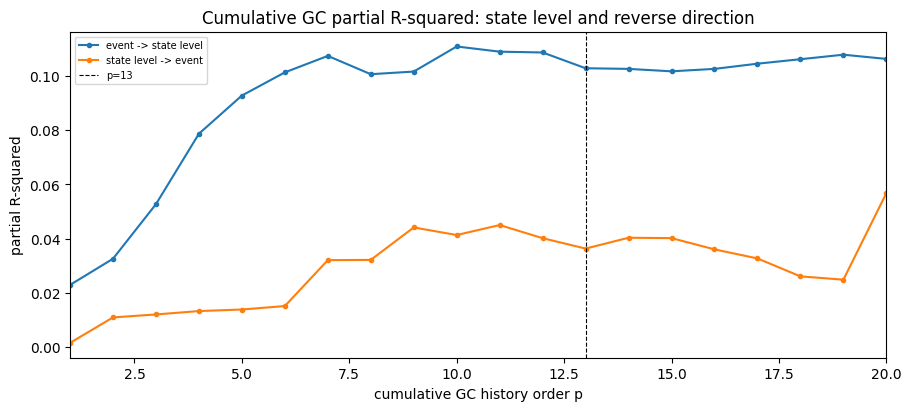

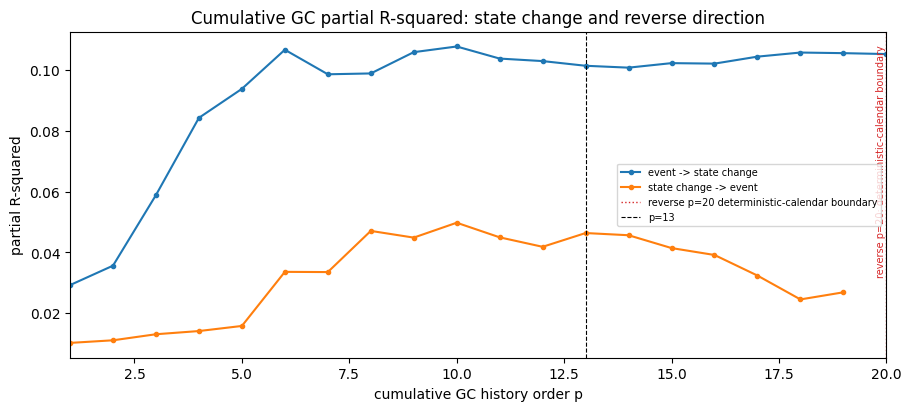

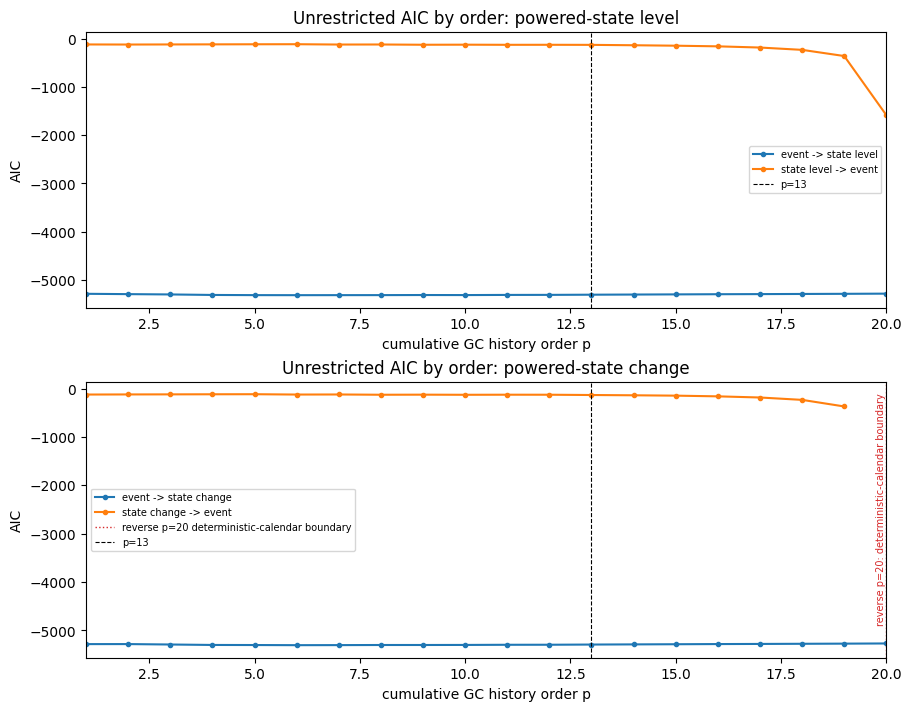

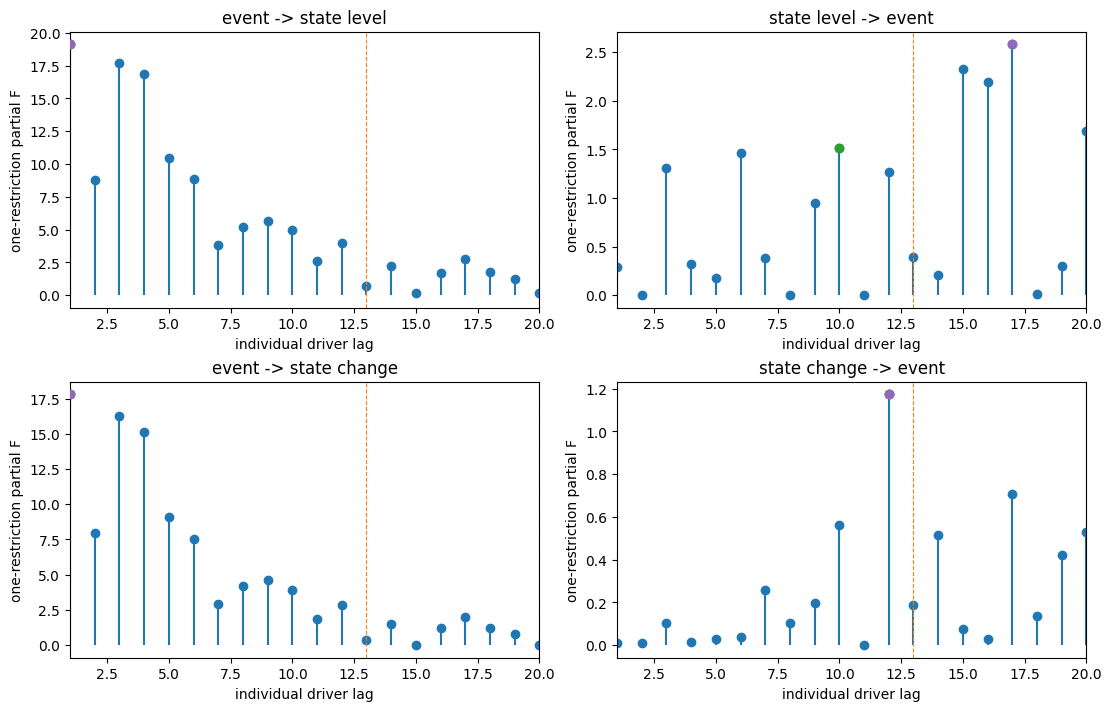

In [6]:
def mark_reverse_boundary(ax, data):
    boundary = data.loc[data.restricted_model_degenerate]
    if not boundary.empty:
        ax.axvline(INTER_EVENT_END, color='tab:red', linestyle=':', linewidth=1, label='reverse p=20 deterministic-calendar boundary')
        ax.annotate('reverse p=20: deterministic-calendar boundary', xy=(INTER_EVENT_END, .96), xycoords=('data','axes fraction'), ha='right', va='top', rotation=90, fontsize=7, color='tab:red')

def plot_gc_orders(target_name,title):
    data=gc_scan.loc[gc_scan.target.eq(target_name)]; fig,ax=plt.subplots(figsize=(9,4),constrained_layout=True)
    for direction,subset in data.groupby('direction'):
        ax.plot(subset.lag_order,subset.partial_R_squared,marker='o',markersize=3,label=direction)
        mark_reverse_boundary(ax, subset)
    ax.axvline(DIRECT_END,color='black',linestyle='--',linewidth=.8,label='p=13')
    ax.set(title=title,xlabel='cumulative GC history order p',ylabel='partial R-squared',xlim=(1,GC_MAX_ORDER)); ax.legend(fontsize=7); plt.show()
plot_gc_orders('Powered-state level','Cumulative GC partial R-squared: state level and reverse direction')
plot_gc_orders('Powered-state change','Cumulative GC partial R-squared: state change and reverse direction')
fig,axes=plt.subplots(2,1,figsize=(9,7),constrained_layout=True)
for ax,target_name in zip(axes,['Powered-state level','Powered-state change']):
    for direction,subset in gc_scan.loc[gc_scan.target.eq(target_name)].groupby('direction'):
        ax.plot(subset.lag_order,subset.unrestricted_AIC,marker='o',markersize=3,label=direction)
        mark_reverse_boundary(ax, subset)
    ax.axvline(DIRECT_END,color='black',linestyle='--',linewidth=.8,label='p=13')
    ax.set(title=f'Unrestricted AIC by order: {target_name.lower()}',xlabel='cumulative GC history order p',ylabel='AIC',xlim=(1,GC_MAX_ORDER)); ax.legend(fontsize=7)
plt.show()
fig,axes=plt.subplots(2,2,figsize=(11,7),constrained_layout=True)
for ax,(_,direction,_,_) in zip(axes.ravel(),gc_specs):
    data=individual_lag_table.loc[individual_lag_table.direction.eq(direction)]; ax.stem(data.lag,data.partial_F_statistic,basefmt=' '); ax.axvline(DIRECT_END,color='tab:orange',linestyle='--',linewidth=.8); ax.axvline(INTER_EVENT_END,color='tab:red',linestyle='--',linewidth=.8)
    for label,color in [('direct response lag=1..13','tab:green'),('strict inter-event lag=1..20','tab:purple')]:
        row=strongest_individual_lag_table.loc[(strongest_individual_lag_table.direction.eq(direction))&(strongest_individual_lag_table['lag window'].eq(label))].iloc[0]; ax.scatter(row['strongest lag'],row['partial F-statistic'],color=color,zorder=4)
    ax.set(title=direction,xlabel='individual driver lag',ylabel='one-restriction partial F',xlim=(1,GC_MAX_ORDER))
plt.show()

## 7. Compact sensitivity and validation

The 10-bin TDMI curve is primary because it was fixed before inspection. The small 5/10/15-bin table is a sensitivity diagnostic, not a data-driven estimator choice. Silent assertions cover timing, common samples, leakage protection, Holm adjustment and prior benchmark reproduction.

In [7]:
sensitivity_rows=[]
for target_name,event,target in [('Powered-state level',level_table.event,level_table.state),('Powered-state change',change_table.event,change_table.state_change)]:
    for bins in (5,10,15):
        summary=summarise_tdmi_windows(compute_tdmi_curve(event,target,bins),target_name).set_index('window'); sensitivity_rows.append({'target':target_name,'quantile bins':bins,'direct peak lag':int(summary.loc['direct response','best lag']),'direct peak TDMI':float(summary.loc['direct response','TDMI value']),'inter-event peak lag':int(summary.loc['strict inter-event','best lag']),'inter-event peak TDMI':float(summary.loc['strict inter-event','TDMI value']),'global positive peak lag':int(summary.loc['global positive','best lag']),'global positive peak TDMI':float(summary.loc['global positive','TDMI value']),'global negative peak lag':int(summary.loc['global negative','best lag']),'global negative peak TDMI':float(summary.loc['global negative','TDMI value'])})
tdmi_sensitivity_table=pd.DataFrame(sensitivity_rows); display(tdmi_sensitivity_table.style.format({col:'{:.6f}' for col in tdmi_sensitivity_table if 'TDMI' in col}))

,target,quantile bins,direct peak lag,direct peak TDMI,inter-event peak lag,inter-event peak TDMI,global positive peak lag,global positive peak TDMI,global negative peak lag,global negative peak TDMI
0,Powered-state level,5,1,0.002223,1,0.002223,22,0.002397,-20,0.003303
1,Powered-state level,10,5,0.009329,5,0.009329,26,0.011406,-34,0.010405
2,Powered-state level,15,10,0.015953,20,0.016155,31,0.016950,-32,0.016731
3,Powered-state change,5,3,0.015729,3,0.015729,3,0.015729,-17,0.015299
4,Powered-state change,10,1,0.022854,1,0.022854,1,0.022854,-17,0.023674
5,Powered-state change,15,1,0.024451,1,0.024451,30,0.027137,-15,0.024862


In [8]:
def legacy_one_lag_forward_f(target,driver):
    y=np.asarray(target,float)[1:]; yl=np.asarray(target,float)[:-1]; dl=np.asarray(driver,float)[:-1]; r=sm.OLS(y,sm.add_constant(yl)).fit(); u=sm.OLS(y,sm.add_constant(np.column_stack([yl,dl]))).fit(); return float((r.ssr-u.ssr)/(u.ssr/u.df_resid))
old={'level_p1_F':12.094457,'change_p1_F':14.862315,'level_direct_lag':5,'level_direct_TDMI':.009329,'change_direct_lag':1,'change_direct_TDMI':.022854}
level_f=legacy_one_lag_forward_f(level_table.state,level_table.event); change_f=legacy_one_lag_forward_f(change_table.state_change,change_table.event); level_direct=tdmi_best_lag_table.loc[(tdmi_best_lag_table.target.eq('Powered-state level'))&(tdmi_best_lag_table.window.eq('direct response'))].iloc[0]; change_direct=tdmi_best_lag_table.loc[(tdmi_best_lag_table.target.eq('Powered-state change'))&(tdmi_best_lag_table.window.eq('direct response'))].iloc[0]
assert all(scan.n_observations.nunique()==1 for _,scan in gc_scan.groupby('direction')) and DIRECT_END==13 and INTER_EVENT_END==20 and NEXT_EVENT_BOUNDARY==21
assert set(gc_scan.direction)=={spec[1] for spec in gc_specs} and np.array_equal(level_tdmi.lag,np.arange(-34,35)) and np.array_equal(change_tdmi.lag,np.arange(-34,35))
assert individual_lag_table.Holm_adjusted_p_value.notna().all() and not gc_order_selection_table.empty and not strongest_individual_lag_table.empty and not tdmi_best_lag_table.empty
assert np.isclose(level_f,old['level_p1_F'],rtol=1e-6) and np.isclose(change_f,old['change_p1_F'],rtol=1e-6)
assert int(level_direct['best lag'])==old['level_direct_lag'] and np.isclose(level_direct['TDMI value'],old['level_direct_TDMI'],atol=1e-6) and int(change_direct['best lag'])==old['change_direct_lag'] and np.isclose(change_direct['TDMI value'],old['change_direct_TDMI'],atol=1e-6)
reverse_rows = gc_scan.loc[gc_scan.direction.isin(REVERSE_GC_DIRECTIONS)]
reverse_boundary = reverse_rows.loc[reverse_rows.lag_order.eq(INTER_EVENT_END)]
degenerate_reverse_rows = reverse_rows.loc[reverse_rows.restricted_model_degenerate]
forward_rows = gc_scan.loc[~gc_scan.direction.isin(REVERSE_GC_DIRECTIONS)]
assert (reverse_rows.loc[reverse_rows.restricted_residual_variance.le(GC_DEGENERACY_TOL),'restricted_model_degenerate']).all()
assert not degenerate_reverse_rows.empty and degenerate_reverse_rows[['F_statistic','p_value','partial_R_squared','unrestricted_AIC','unrestricted_BIC']].isna().all().all()
assert not forward_rows.restricted_model_degenerate.any() and forward_rows[['F_statistic','p_value','partial_R_squared']].notna().all().all()
assert set(reverse_boundary.lag_order) == {INTER_EVENT_END}
for _, excluded in degenerate_reverse_rows.iterrows():
    selected = gc_order_selection_table.loc[gc_order_selection_table.direction.eq(excluded.direction), ['AIC-selected order','BIC-selected order','max-partial-R2 order']]
    assert not selected.eq(excluded.lag_order).any().any()
assert gc_order_selection_table.loc[(gc_order_selection_table.direction.eq('state change -> event')) & (gc_order_selection_table['search window'].eq('strict inter-event p=1..20')),'any order excluded as degenerate'].all()
print('Reverse-GC deterministic-calendar degeneracy handled correctly.')

Reverse-GC deterministic-calendar degeneracy handled correctly.


## 8. Interpretation

GC is predictive causality, not proof of structural causation. Reverse GC can reflect deterministic event-calendar phase; individual distributed-lag coefficients can be unstable under multicollinearity. TDMI is a dependence measure, not proof of structural causality; negative-lag dependence can arise through persistence and periodicity, while scan-boundary maxima and post-hoc scanning require caution.

In [9]:
import nbformat
def compact_selection(direction): return '; '.join(f"{r['search window']}: AIC p={int(r['AIC-selected order'])}, BIC p={int(r['BIC-selected order'])}" for _,r in gc_order_selection_table.loc[gc_order_selection_table.direction.eq(direction)].iterrows())
def compact_lags(direction): return '; '.join(f"{r['lag window']}: lag {int(r['strongest lag'])}, Holm={'yes' if r['survives Holm correction'] else 'no'}" for _,r in strongest_individual_lag_table.loc[strongest_individual_lag_table.direction.eq(direction)].iterrows())
def compact_tdmi(target):
    r=tdmi_best_lag_table.loc[tdmi_best_lag_table.target.eq(target)].set_index('window'); return f"direct {int(r.loc['direct response','best lag'])}, inter-event {int(r.loc['strict inter-event','best lag'])}, positive {int(r.loc['global positive','best lag'])}, negative {int(r.loc['global negative','best lag'])}, nonzero global {int(r.loc['global nonzero','best lag'])}"
text=f"""### Result-specific conclusions

- Event to state level: {compact_selection('event -> state level')}; strongest conditional lags are {compact_lags('event -> state level')}.
- State level to event: {compact_selection('state level -> event')}; reverse GC is a calendar-phase diagnostic, not structural state-to-event causation. At p=20 the event history can reconstruct the deterministic period-21 calendar in a phase-aligned reverse design; any numerically degenerate boundary is excluded from order selection, while non-degenerate reverse orders remain descriptive calendar-phase diagnostics. Strongest lags are {compact_lags('state level -> event')}.
- Event to state change: {compact_selection('event -> state change')}; strongest conditional lags are {compact_lags('event -> state change')}.
- State change to event: {compact_selection('state change -> event')}; strongest lags are {compact_lags('state change -> event')}, again without a structural reverse-causation claim; any numerically degenerate p=20 deterministic-calendar boundary is excluded from inference.
- TDMI peak lags for level are {compact_tdmi('Powered-state level')}. TDMI peak lags for change are {compact_tdmi('Powered-state change')}. Forward GC remains the primary event-to-volatility predictive analysis; this reverse-GC boundary correction does not alter forward GC or TDMI. Direct/inter-event TDMI timing can differ from cumulative-GC order because they are different objects.

AIC is primary and BIC is parsimonious sensitivity; neither selected order identifies an individual causal lag. Individual-lag inference is Holm-adjusted, but adjacent periodic histories remain collinear. The 5/10/15-bin table makes descriptive TDMI peak sensitivity visible."""
display(Markdown(text))
source=nbformat.read("01_dense_periodic_n1_gc_tdmi.ipynb",as_version=4); original_code_lines=745; final_code_lines=sum(len(c.source.splitlines()) for c in source.cells if c.cell_type=='code'); reduction=100*(1-final_code_lines/original_code_lines)
print(f'Code lines: original approximately {original_code_lines}; final approximately {final_code_lines}; reduction {reduction:.1f}%; code cells {sum(c.cell_type=="code" for c in source.cells)}.')

### Result-specific conclusions

- Event to state level: direct response p=1..13: AIC p=6, BIC p=1; strict inter-event p=1..20: AIC p=6, BIC p=1; strongest conditional lags are direct response lag=1..13: lag 1, Holm=yes; strict inter-event lag=1..20: lag 1, Holm=yes.
- State level to event: direct response p=1..13: AIC p=13, BIC p=1; strict inter-event p=1..20: AIC p=20, BIC p=20; reverse GC is a calendar-phase diagnostic, not structural state-to-event causation. At p=20 the event history can reconstruct the deterministic period-21 calendar in a phase-aligned reverse design; any numerically degenerate boundary is excluded from order selection, while non-degenerate reverse orders remain descriptive calendar-phase diagnostics. Strongest lags are direct response lag=1..13: lag 10, Holm=no; strict inter-event lag=1..20: lag 17, Holm=no.
- Event to state change: direct response p=1..13: AIC p=6, BIC p=1; strict inter-event p=1..20: AIC p=6, BIC p=1; strongest conditional lags are direct response lag=1..13: lag 1, Holm=yes; strict inter-event lag=1..20: lag 1, Holm=yes.
- State change to event: direct response p=1..13: AIC p=13, BIC p=1; strict inter-event p=1..20: AIC p=19, BIC p=19; strongest lags are direct response lag=1..13: lag 12, Holm=no; strict inter-event lag=1..20: lag 12, Holm=no, again without a structural reverse-causation claim; any numerically degenerate p=20 deterministic-calendar boundary is excluded from inference.
- TDMI peak lags for level are direct 5, inter-event 5, positive 26, negative -34, nonzero global 26. TDMI peak lags for change are direct 1, inter-event 1, positive 1, negative -17, nonzero global -17. Forward GC remains the primary event-to-volatility predictive analysis; this reverse-GC boundary correction does not alter forward GC or TDMI. Direct/inter-event TDMI timing can differ from cumulative-GC order because they are different objects.

AIC is primary and BIC is parsimonious sensitivity; neither selected order identifies an individual causal lag. Individual-lag inference is Holm-adjusted, but adjacent periodic histories remain collinear. The 5/10/15-bin table makes descriptive TDMI peak sensitivity visible.

Code lines: original approximately 745; final approximately 187; reduction 74.9%; code cells 9.
